# Semantic Cache Demo

Demonstrating how semantic caching reduces LLM API costs by
reusing answers to semantically similar questions.

Key concept: we cache by **meaning**, not exact string match.
"What is RAG?" and "Can you explain RAG?" should hit the same cache entry.

In [2]:
import sys
sys.path.insert(0, '..')

from src.cache.semantic_cache import SemanticCache
import numpy as np
import matplotlib.pyplot as plt

cache = SemanticCache()
cache.clear()
print("Cache cleared and ready")

2026-06-23 12:30:38 | INFO | src.cache.semantic_cache | Initialized SemanticCache
2026-06-23 12:30:38 | INFO | src.cache.semantic_cache | Cache cleared
Cache cleared and ready


## Seeding the cache with known Q&A pairs

In [3]:
qa_pairs = [
    ("What is RAG?", "RAG stands for Retrieval Augmented Generation. It combines vector search with LLM generation to answer questions from documents."),
    ("What is a vector embedding?", "A vector embedding is a numerical representation of text that captures semantic meaning. Similar texts produce similar vectors."),
    ("What is fine-tuning?", "Fine-tuning adapts a pretrained model to a specific task by continuing training on domain-specific data."),
    ("What is the attention mechanism?", "Attention allows the model to focus on relevant parts of the input when generating each output token."),
]

model = "mistralai/Mistral-7B-Instruct-v0.3"

for question, answer in qa_pairs:
    cache.set(question, answer, model=model)
    print(f"Cached: {question}")

print(f"\nCache now has {cache.get_stats()['total_entries']} entries")

c:\Users\Snapp\anaconda3\envs\llm-orchestration\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7200.34it/s]


Cached: What is RAG?
Cached: What is a vector embedding?
Cached: What is fine-tuning?
Cached: What is the attention mechanism?

Cache now has 4 entries


## Testing semantic similarity — exact vs paraphrased vs unrelated

In [4]:
test_queries = [
    ("What is RAG?",                          "exact match"),
    ("Can you explain what RAG is?",           "paraphrase"),
    ("Tell me about Retrieval Augmented Generation", "different wording"),
    ("What is machine learning?",              "related but different"),
    ("What is the weather today?",             "completely unrelated"),
]

print(f"Threshold: {cache.similarity_threshold}\n")
print(f"{'Query':<45} {'Type':<25} {'Result':<10} {'Score'}")
print("-"*100)

results = []
for query, query_type in test_queries:
    result = cache.get(query, model=model)
    if result:
        answer, score = result
        status = "HIT"
    else:
        score  = 0.0
        status = "MISS"

    results.append({
        "query": query,
        "type":  query_type,
        "status": status,
        "score": score,
    })
    print(f"{query:<45} {query_type:<25} {status:<10} {score:.4f}")

Threshold: 0.92

Query                                         Type                      Result     Score
----------------------------------------------------------------------------------------------------
2026-06-23 12:31:40 | INFO | src.cache.semantic_cache | Cache HIT
What is RAG?                                  exact match               HIT        1.0000
2026-06-23 12:31:40 | INFO | src.cache.semantic_cache | Cache HIT
Can you explain what RAG is?                  paraphrase                HIT        0.9456
Tell me about Retrieval Augmented Generation  different wording         MISS       0.0000
What is machine learning?                     related but different     MISS       0.0000
What is the weather today?                    completely unrelated      MISS       0.0000


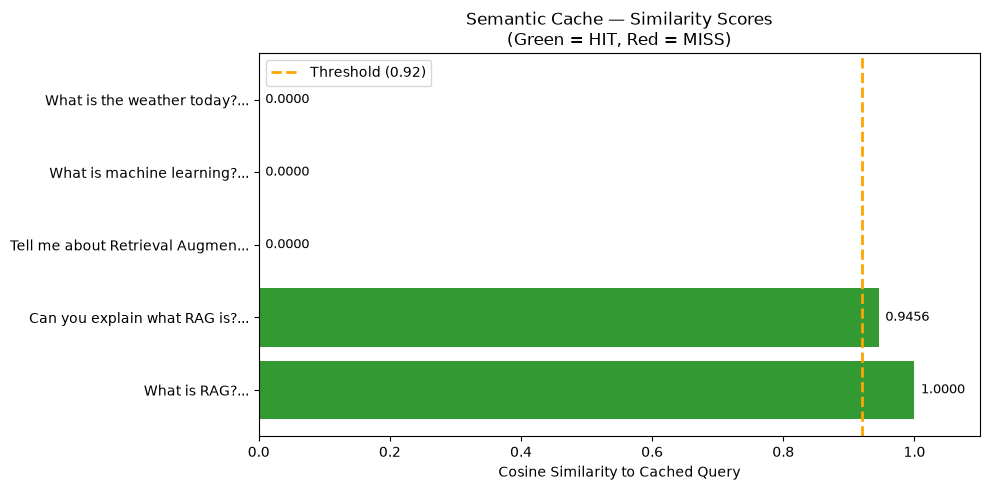

In [5]:
queries_short = [r["query"][:30] + "..." for r in results]
scores        = [r["score"] for r in results]
colors        = ["green" if r["status"] == "HIT" else "red" for r in results]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(queries_short, scores, color=colors, alpha=0.8)
ax.axvline(x=cache.similarity_threshold, color='orange', linestyle='--',
           linewidth=2, label=f'Threshold ({cache.similarity_threshold})')
ax.set_xlabel("Cosine Similarity to Cached Query")
ax.set_title("Semantic Cache — Similarity Scores\n(Green = HIT, Red = MISS)")
ax.set_xlim(0, 1.1)
ax.legend()

for bar, score in zip(bars, scores):
    ax.text(score + 0.01, bar.get_y() + bar.get_height()/2,
            f"{score:.4f}", va='center', fontsize=9)

plt.tight_layout()
plt.savefig("../data/cache_similarity_scores.png", dpi=150)
plt.show()

## Key Insight

The threshold of 0.92 is the critical hyperparameter:
- Too high (0.99): almost nothing matches, low savings
- Too low (0.70): wrong answers get reused (dangerous)
- 0.92: catches paraphrases and rewording while avoiding false positives

Notice "What is machine learning?" scores ~0.75 — related topic but
correctly MISSED because it's asking about something different.